In [1]:
import anndata as ad
import numpy as np
import pandas as pd
from pathlib import Path
import os
import socket
import matplotlib.pyplot as plt
import scanpy as sc

print(f"Running on node: {socket.gethostname()}")
print(os.getcwd())
print(os.path.expanduser("~"))

Running on node: n-62-20-1
/zhome/bf/7/219671/projects/DL_project
/zhome/bf/7/219671


In [2]:
source_path = Path("/work3/s252608/DL_project/data/raw")

data = ['bulk_processed_genes.h5ad',
        'sc_processed_genes.h5ad']

In [10]:
for d in data:
    adata = ad.read_h5ad(f'{source_path}/{d}', backed='r')
    print(f'\n{d} loaded')
    sample_slice = adata.X[:100, :100]
    if hasattr(sample_slice, "toarray"):
        sample_slice = sample_slice.toarray()

    print(f"Max value in slice: {np.max(sample_slice)}")
    print(f'log1p: {adata.uns["log1p"]}')

    non_zero = sample_slice[sample_slice > 0]
    print(f"First non-zero values: {non_zero[:5]}")


bulk_processed_genes.h5ad loaded
Max value in slice: 289906
log1p: {}
First non-zero values: [ 42 285  17  78 166]

sc_processed_genes.h5ad loaded
Max value in slice: 16350
log1p: {}
First non-zero values: [ 4 19 70 13  1]


In [5]:
exp_data = ad.read_h5ad(f'{source_path}/bulk_processed_genes.h5ad', backed='r')
iso_data = ad.read_h5ad(f'{source_path}/bulk_processed_transcripts.h5ad', backed='r')

In [6]:
sub_exp_data = exp_data[:1000, :1000].to_memory()
sub_iso_data = iso_data[:1000, :1000].to_memory()

In [7]:
sc.pp.log1p(sub_exp_data)
sc.pp.log1p(sub_iso_data)

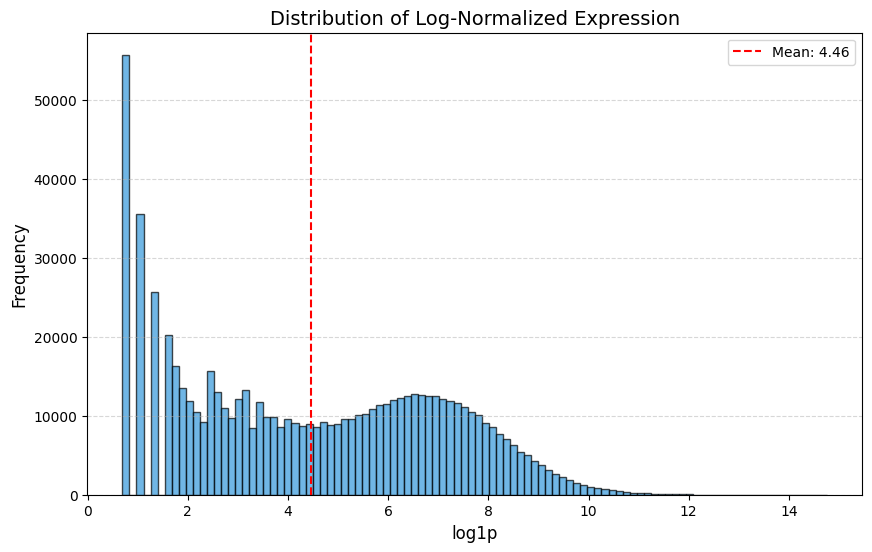

In [8]:
nonzero_exp = sub_exp_data.X.data

plt.figure(figsize=(10, 6))
plt.hist(nonzero_exp, bins=100, color='#3498db', edgecolor='black', alpha=0.7)

plt.title('Distribution of Log-Normalized Expression', fontsize=14)
plt.xlabel('log1p', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

mean_val = np.mean(nonzero_exp)
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.legend()

plt.show()

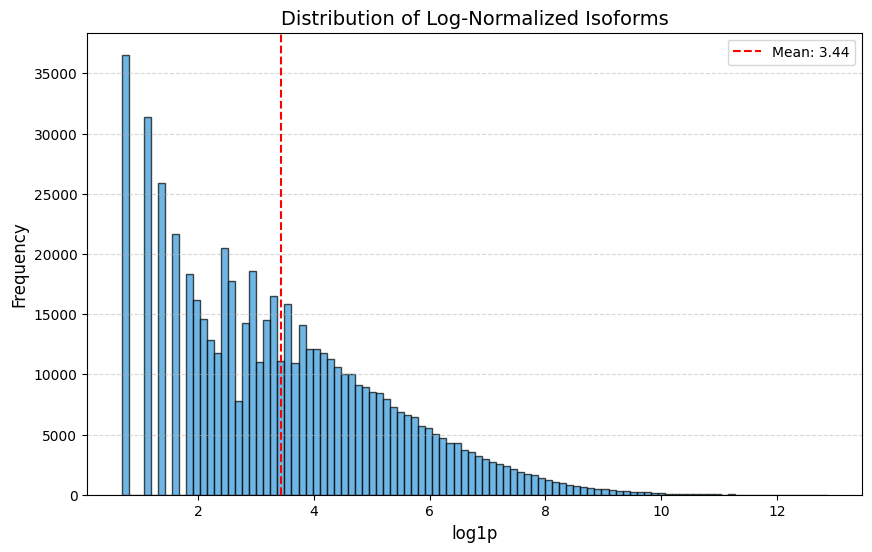

In [9]:
nonzero_exp = sub_iso_data.X.data

plt.figure(figsize=(10, 6))
plt.hist(nonzero_exp, bins=100, color='#3498db', edgecolor='black', alpha=0.7)

plt.title('Distribution of Log-Normalized Isoforms', fontsize=14)
plt.xlabel('log1p', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

mean_val = np.mean(nonzero_exp)
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.legend()

plt.show()

In [10]:
multi_iso_genes = exp_data.uns['multi_isoform_genes']
target_gene = multi_iso_genes[0] 
target_isoforms = exp_data.uns['gene_to_transcripts'][target_gene]

print(f'Comparing target gene {target_gene} with its corresponding isoforms {target_isoforms}')

Comparing target gene A1BG with its corresponding isoforms ['ENST00000596924' 'ENST00000595014' 'ENST00000598345' 'ENST00000600966']


In [11]:
gene_vector = exp_data[:, target_gene].to_memory().X.toarray().flatten()

iso_vectors = {}
for iso in target_isoforms:
    if iso in iso_data.var_names:
        iso_vectors[iso] = iso_data[:, iso].to_memory().X.toarray().flatten()

df_comp = pd.DataFrame(iso_vectors)
df_comp['TOTAL_GENE_SUM'] = gene_vector

df_comp_log = np.log1p(df_comp)

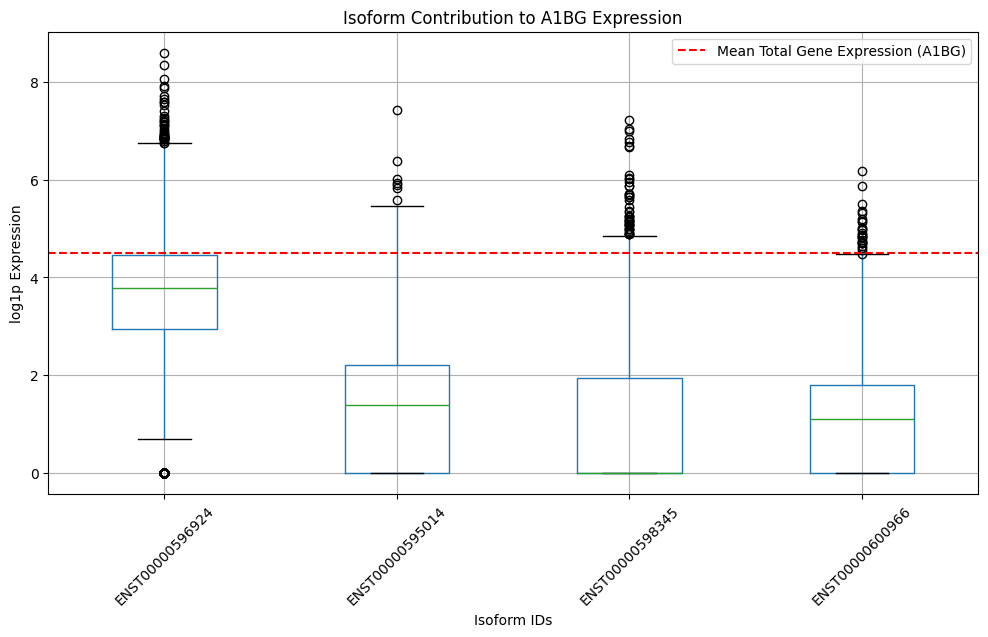

In [12]:
plt.figure(figsize=(12, 6))

df_comp_log.drop(columns=['TOTAL_GENE_SUM']).boxplot()

plt.axhline(df_comp_log['TOTAL_GENE_SUM'].mean(), color='red', linestyle='--', 
            label=f'Mean Total Gene Expression ({target_gene})')

plt.title(f"Isoform Contribution to {target_gene} Expression")
plt.ylabel("log1p Expression")
plt.xlabel("Isoform IDs")
plt.xticks(rotation=45)
plt.legend()
plt.show()